In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use("ggplot")


In [2]:
filename = "./data/tradebook.csv"

In [3]:
df = pd.read_csv(filename)

In [4]:
df["total"] = df["quantity"] * df["price"]
df["tdate"] = pd.to_datetime(df["trade_date"])

In [5]:
df.head()

,symbol,isin,trade_date,exchange,segment,series,trade_type,auction,quantity,price,trade_id,order_id,order_execution_time,total,tdate
0,ZOMATO,INE758T01015,2023-01-06,BSE,EQ,A,sell,False,258.0,55.60,31052600,1672982327785688929,2023-01-06T11:00:49,14344.8,2023-01-06
1,TATAMOTORS,INE155A01022,2023-01-06,BSE,EQ,A,sell,False,71.0,385.10,3030500,1672982564928018147,2023-01-06T11:00:56,27342.1,2023-01-06
2,LICI,INE0J1Y01017,2023-01-06,BSE,EQ,A,sell,False,12.0,719.25,2142100,1672981587994233245,2023-01-06T11:01:36,8631.0,2023-01-06
3,LICI,INE0J1Y01017,2023-01-06,BSE,EQ,A,sell,False,37.0,719.20,2142800,1672981587994233245,2023-01-06T11:01:36,26610.4,2023-01-06
4,LICI,INE0J1Y01017,2023-01-06,BSE,EQ,A,sell,False,60.0,719.15,2143000,1672981587994233245,2023-01-06T11:01:36,43149.0,2023-01-06


In [245]:
df["quantity"].max()

500.0

In [246]:
len(df[(df["symbol"] == "INFY") & (df["trade_type"] == "buy")])

35

In [247]:
import datetime

In [248]:
date = datetime.datetime(2023,2,16)

In [249]:
date

datetime.datetime(2023, 2, 16, 0, 0)

In [250]:
total_sell_till_104 = df[(df["tdate"] <= date) & (df["symbol"] == "INFY") & (df["trade_type"] == "sell")]["quantity"].sum()

In [251]:
total_buy_till_104 = df[(df["tdate"] <= date) & (df["symbol"] == "INFY") & (df["trade_type"] == "buy")]["quantity"].sum()

In [252]:
total_buy_till_104 - total_sell_till_104

0.0

In [253]:
total_buy_after = df[(df["tdate"] > date) & (df["symbol"] == "INFY") & (df["trade_type"] == "buy")]["quantity"].sum()

In [254]:
total_buy_after

455.0

In [255]:
total_sell_after = df[(df["tdate"] > date) & (df["symbol"] == "INFY") & (df["trade_type"] == "sell")]["quantity"].sum()

In [256]:
total_sell_after

0.0

In [257]:
total_buy_amount = df[(df["tdate"] > date) & (df["symbol"] == "INFY") & (df["trade_type"] == "buy")]["total"].sum()

In [258]:
avg_buy = total_buy_amount / total_buy_after

In [259]:
avg_buy

1406.4638461538464

In [260]:
dates = df[(df["tdate"] > date) & (df["symbol"] == "INFY") & (df["trade_type"] == "buy")]["tdate"]

In [261]:
dates

109   2023-02-17
127   2023-02-22
132   2023-02-23
139   2023-02-24
142   2023-02-24
143   2023-02-24
145   2023-02-24
151   2023-02-28
152   2023-02-28
153   2023-02-28
160   2023-03-01
164   2023-03-02
167   2023-03-06
168   2023-03-06
177   2023-03-08
178   2023-03-08
182   2023-03-13
192   2023-03-15
218   2023-04-17
221   2023-04-17
222   2023-04-17
224   2023-04-19
225   2023-04-20
227   2023-04-21
228   2023-04-21
238   2023-04-25
Name: tdate, dtype: datetime64[ns]

In [262]:
quantities = df[(df["tdate"] > date) & (df["symbol"] == "INFY") & (df["trade_type"] == "buy")]["quantity"]

In [263]:
quantities

109    50.0
127    20.0
132    10.0
139    30.0
142     6.0
143     4.0
145    20.0
151    13.0
152     1.0
153     1.0
160    10.0
164    30.0
167     1.0
168     9.0
177     3.0
178    27.0
182    10.0
192    30.0
218    20.0
221    20.0
222    20.0
224    30.0
225    30.0
227    27.0
228     3.0
238    30.0
Name: quantity, dtype: float64

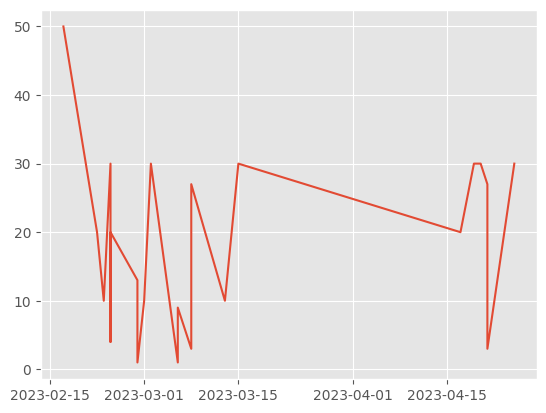

In [264]:
plt.plot(dates, quantities)

In [265]:
price = df[(df["tdate"] > date) & (df["symbol"] == "INFY") & (df["trade_type"] == "buy")]["price"]

In [266]:
data = {"x": dates, "y": price, "size": quantities }

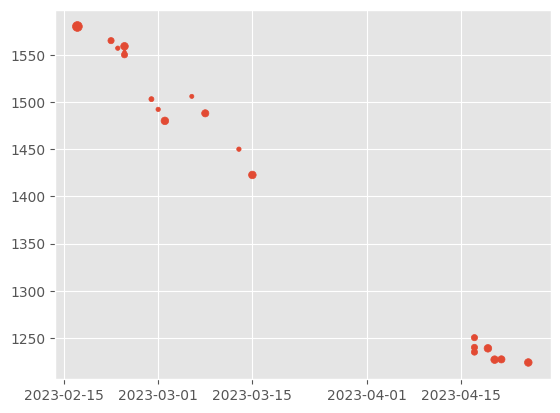

In [267]:
plt.scatter("x", "y", "size", data=data)

In [268]:
all_trade_dates = df[df["tdate"] > datetime.datetime(2023, 3, 31)]["tdate"]

In [269]:
all_trade_dates

200   2023-04-10
201   2023-04-10
202   2023-04-10
203   2023-04-10
204   2023-04-11
         ...    
262   2023-05-03
263   2023-05-03
264   2023-05-03
265   2023-05-04
266   2023-05-04
Name: tdate, Length: 67, dtype: datetime64[ns]

In [270]:
all_trade_counts = df[df["tdate"] > datetime.datetime(2023, 3, 31)]["quantity"]

In [271]:
data = { "x": all_trade_dates, "y": all_trade_counts}

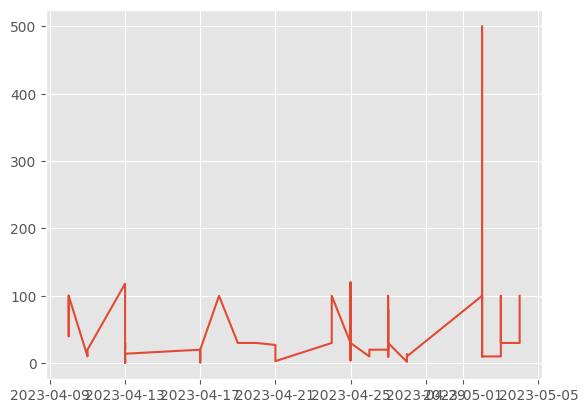

In [272]:
plt.plot(all_trade_dates, all_trade_counts)

In [273]:
df.head(1)

,symbol,isin,trade_date,exchange,segment,series,trade_type,auction,quantity,price,trade_id,order_id,order_execution_time,total,tdate
0,ZOMATO,INE758T01015,2023-01-06,BSE,EQ,A,sell,False,258.0,55.6,31052600,1672982327785688929,2023-01-06T11:00:49,14344.8,2023-01-06


In [274]:
all_transactions_in_current_fy = df[df["tdate"] > datetime.datetime(2023, 4, 1)]

In [275]:
no_transactions_in_current_fy = len(all_transactions_in_current_fy)

In [276]:
no_transactions_in_current_fy

67

In [277]:
all_buy_transactions_in_current_fy = df[(df["tdate"] > datetime.datetime(2023, 4, 1)) & (df["trade_type"] == "buy")]

In [278]:
all_sell_transactions_in_current_fy = df[(df["tdate"] > datetime.datetime(2023, 4, 1)) & (df["trade_type"] == "sell")]

In [279]:
quantity_purchased_in_current_fy = all_buy_transactions_in_current_fy["quantity"].sum()

In [280]:
quantity_purchased_in_current_fy

1720.0

In [281]:
amount_purcahsed_in_current_fy = all_buy_transactions_in_current_fy["total"].sum()

In [282]:
revenue_booked_in_current_fy = all_sell_transactions_in_current_fy["total"].sum()

In [283]:
revenue_booked_in_current_fy

521430.0

In [284]:
profit = revenue_booked_in_current_fy - amount_purcahsed_in_current_fy

In [285]:
profit

-179761.19999999995

In [286]:
df.shape

(267, 15)

In [287]:
all_buy_transactions_in_current_fy.shape

(61, 15)

In [288]:
df.columns

Index(['symbol', 'isin', 'trade_date', 'exchange', 'segment', 'series',
       'trade_type', 'auction', 'quantity', 'price', 'trade_id', 'order_id',
       'order_execution_time', 'total', 'tdate'],
      dtype='object')

In [289]:
df = df[['symbol', 'trade_date', 'exchange',
       'trade_type', 'quantity', 'price',
        'total', 'tdate']].copy()

In [290]:
df

,symbol,trade_date,exchange,trade_type,quantity,price,total,tdate
0,ZOMATO,2023-01-06,BSE,sell,258.0,55.60,14344.8,2023-01-06
1,TATAMOTORS,2023-01-06,BSE,sell,71.0,385.10,27342.1,2023-01-06
2,LICI,2023-01-06,BSE,sell,12.0,719.25,8631.0,2023-01-06
3,LICI,2023-01-06,BSE,sell,37.0,719.20,26610.4,2023-01-06
4,LICI,2023-01-06,BSE,sell,60.0,719.15,43149.0,2023-01-06
...,...,...,...,...,...,...,...,...
262,SUNPHARMA,2023-05-03,NSE,buy,10.0,965.00,9650.0,2023-05-03
263,SOUTHBANK,2023-05-03,NSE,buy,100.0,16.50,1650.0,2023-05-03
264,FEDERALBNK,2023-05-03,NSE,buy,30.0,137.20,4116.0,2023-05-03
265,FEDERALBNK,2023-05-04,NSE,buy,30.0,137.65,4129.5,2023-05-04


In [291]:
df.isna().sum()

symbol        0
trade_date    0
exchange      0
trade_type    0
quantity      0
price         0
total         0
tdate         0
dtype: int64

In [292]:
df = df.rename(columns={"tdate":"date"}).copy()

In [293]:
df.query('symbol == "INFY" and trade_type== "buy"')

,symbol,trade_date,exchange,trade_type,quantity,price,total,date
5,INFY,2023-01-11,NSE,buy,12.0,1490.05,17880.60,2023-01-11
6,INFY,2023-01-11,NSE,buy,67.0,1490.35,99853.45,2023-01-11
7,INFY,2023-01-11,NSE,buy,1.0,1490.10,1490.10,2023-01-11
17,INFY,2023-01-20,NSE,buy,5.0,1539.85,7699.25,2023-01-20
18,INFY,2023-01-20,NSE,buy,25.0,1539.85,38496.25,2023-01-20
19,INFY,2023-01-20,NSE,buy,60.0,1539.85,92391.00,2023-01-20
20,INFY,2023-01-20,NSE,buy,5.0,1539.80,7699.00,2023-01-20
21,INFY,2023-01-20,NSE,buy,5.0,1539.80,7699.00,2023-01-20
70,INFY,2023-02-06,NSE,buy,20.0,1570.00,31400.00,2023-02-06
109,INFY,2023-02-17,NSE,buy,50.0,1580.00,79000.00,2023-02-17


In [294]:
df["symbol"].value_counts()

INFY          39
TATAMOTORS    32
BAJAJFINSV    25
IRCTC         22
SUNPHARMA     20
HDFCBANK      19
KABRAEXTRU    16
RELIANCE      12
ADANIPORTS    11
TATASTEEL      9
MUTHOOTFIN     8
VEDL           8
JSWSTEEL       8
IDFCFIRSTB     6
WONDERLA       5
MAHABANK       5
VOLTAS         4
PVR            4
POLICYBZR      4
LICI           3
SOUTHBANK      3
FEDERALBNK     2
GOLDBEES       1
ZOMATO         1
Name: symbol, dtype: int64

Text(0, 0.5, 'Trade counts')

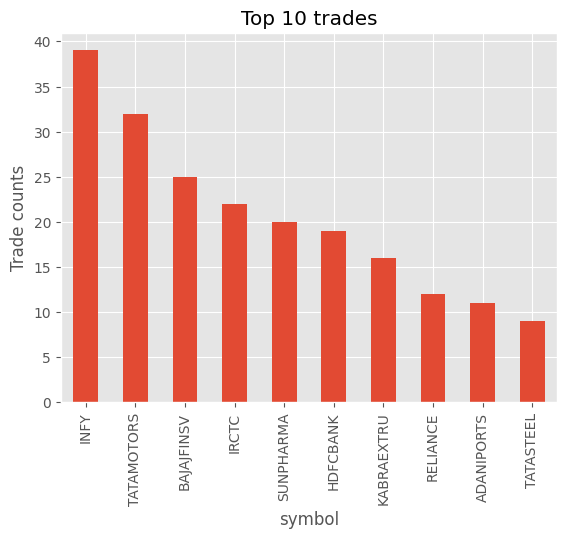

In [295]:
ax = df["symbol"].value_counts().head(10).plot(kind="bar", title="Top 10 trades")
ax.set_xlabel("symbol")
ax.set_ylabel("Trade counts")

Text(0, 0.5, 'Trade counts')

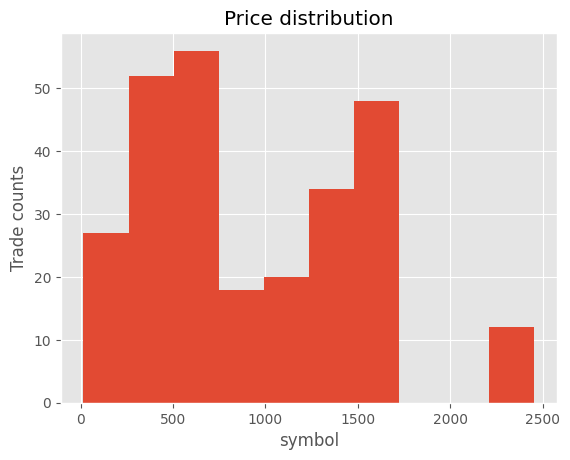

In [305]:
ax = df["price"].plot(kind="hist", title="Price distribution")
ax.set_xlabel("symbol")
ax.set_ylabel("Trade counts")

In [298]:
!pip install scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 8.8 MB/s eta 0:00:00m eta 0:00:0100:0101m

[notice] A new release of pip available: 22.3.1 -> 23.1.2
[notice] To update, run: pip install --upgrade pip


Text(0.5, 0, 'Price')

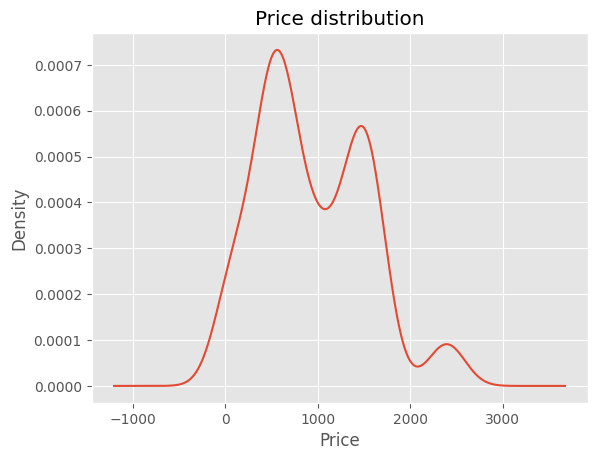

In [304]:
ax = df["price"].plot(kind="kde", title="Price distribution")
ax.set_xlabel("Price")

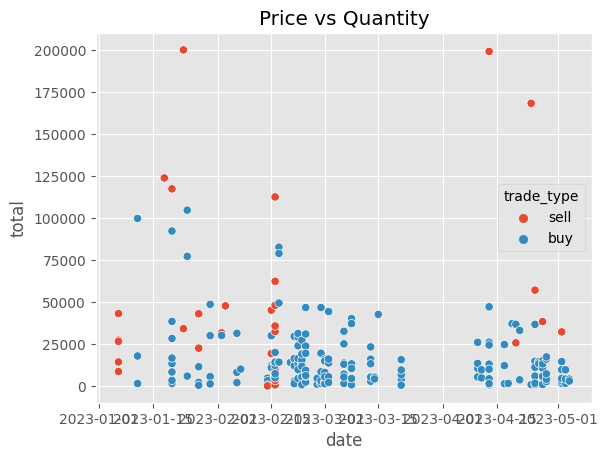

In [317]:
ax = sns.scatterplot(x="date", y="total", hue="trade_type", data=df)
ax.set_title("Price vs Quantity")
plt.show()

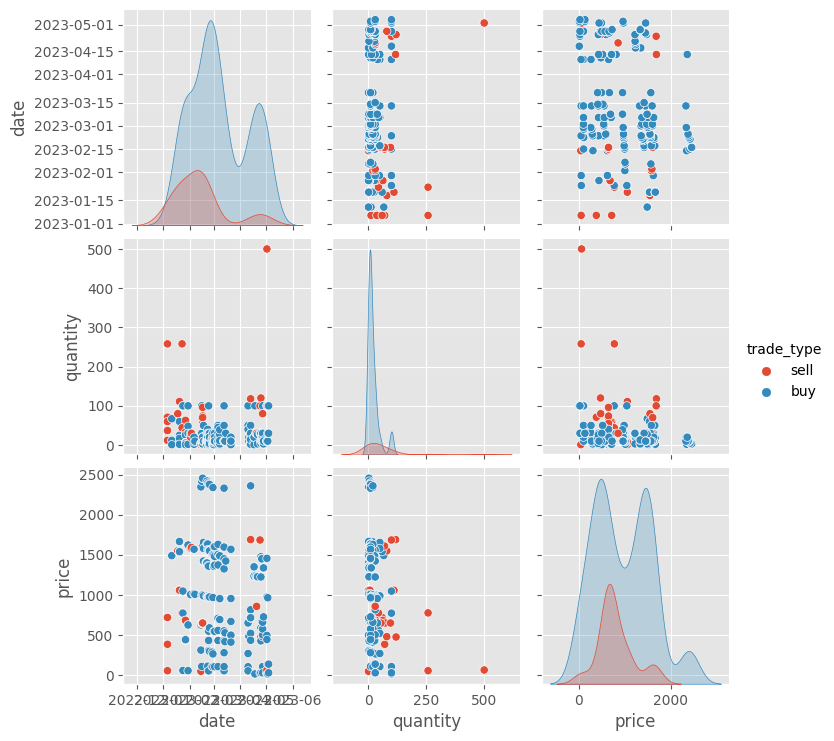

In [319]:
sns.pairplot(df, vars=["date", "quantity", "price"], hue="trade_type")

In [322]:
df_corr = df[["price", "quantity"]].dropna().corr()  # correlation 
df_corr 

,price,quantity
price,1.00000,-0.26254
quantity,-0.26254,1.00000


<AxesSubplot: >

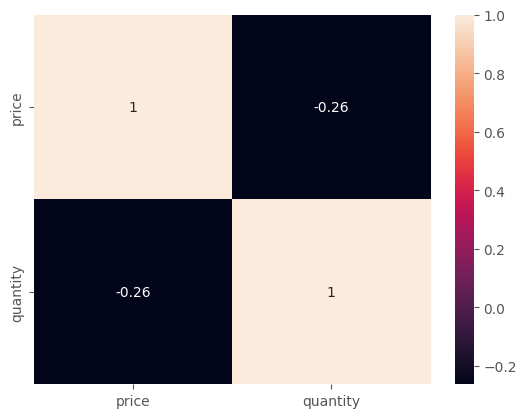

In [324]:
sns.heatmap(df_corr, annot=True)

In [326]:
df.head()

,symbol,trade_date,exchange,trade_type,quantity,price,total,date
0,ZOMATO,2023-01-06,BSE,sell,258.0,55.60,14344.8,2023-01-06
1,TATAMOTORS,2023-01-06,BSE,sell,71.0,385.10,27342.1,2023-01-06
2,LICI,2023-01-06,BSE,sell,12.0,719.25,8631.0,2023-01-06
3,LICI,2023-01-06,BSE,sell,37.0,719.20,26610.4,2023-01-06
4,LICI,2023-01-06,BSE,sell,60.0,719.15,43149.0,2023-01-06


In [336]:

df[['symbol', 'trade_type', 'quantity', 'price']].groupby('symbol')['quantity'].agg(['mean', 'count']).query("count > 10").sort_values('count')

,mean,count
symbol,,
ADANIPORTS,29.090909,11
RELIANCE,8.333333,12
KABRAEXTRU,15.000000,16
HDFCBANK,22.947368,19
SUNPHARMA,24.000000,20
IRCTC,26.227273,22
BAJAJFINSV,6.000000,25
TATAMOTORS,14.718750,32
INFY,21.923077,39


<Figure size 1500x480 with 0 Axes>